This notebook records the creation of the `SHENDURE_BOUNDS` preset object and some plots illustrating modeling choices.

Setup.

In [16]:
import scMPRAforge as scm
#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='8GB')
client=Client(cluster)

2025-08-26 14:54:54,315 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:39871' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'lambda-dc0a5f62413d66b107736b3aa270ee0e', 'lambda-6fec486448d55bf3f55a9c5342d2d244', 'lambda-5c40a975e87b8a7b8c2e2e24d0cece0f', 'lambda-d5ca72d5e31111ebd7e78ac41b977f17', 'lambda-6e6089c8d70d305f96b79507a1732e9b', 'lambda-3a7ff2f9962743e71f96e2308c44e34e', 'lambda-00b9e7bcaba1f9f69923b4453b89ffcf', 'lambda-2603c9c7a03178279c4edbee107f5bae', 'lambda-35163c1e13534f3e119f7c38f50c72fb', 'lambda-97493779e2ffdb0843e50d8425353de0', 'lambda-41cd21842eca6c38c18c84ee81bee77d', 'lambda-8a237df3f6b46d3abe2004055ced0eeb', 'lambda-b975d158c7f6ecd0286be77884987173', 'lambda-e759a893ef4b5d583feba4c9f5b033b4', 'lambda-e173737250ef566066c8f52a24926364', 'lambda-ade885eb49b989adb1fdae201785313e', 'lambda-17b68fc2a24994bf3f995644f524cac8', 'lambda-afafb46013471f63623ab26a9b7801b4', 'lambda-26056d08dc843dfcbadcd455b5c1

Load shendure ortho object.

In [2]:
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="ortho_primordial_v3"
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
primordial=scm.ortho.load(client,path,name)

Create the bounds

In [3]:
shendure_bounds=scm.Bounds.from_ortho(primordial)

Let's make some plots showing why we chose nb:

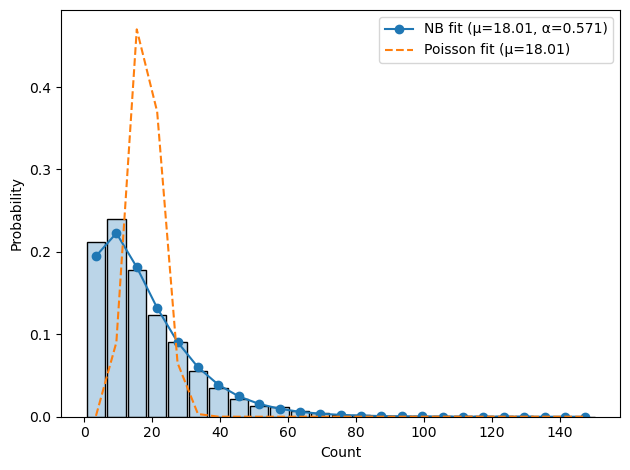

In [22]:
shendure_bounds.transfection_model.plot()

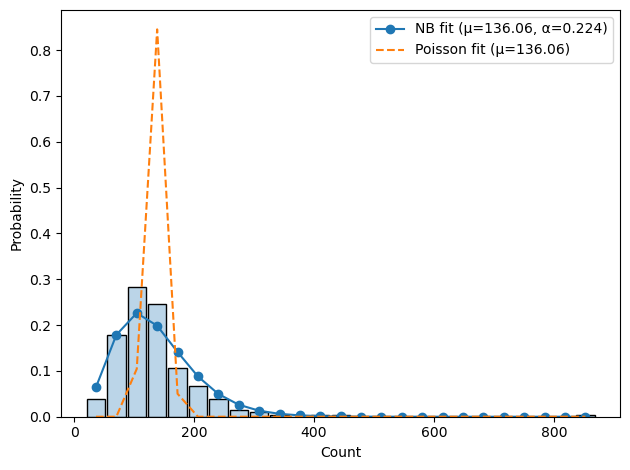

In [23]:
shendure_bounds.library_model.plot()

Now let's save the object:

In [24]:
shendure_bounds.to_tgz("scMPRAforge/presets/shendure_bounds.tgz")

In [25]:
cluster.close()